In [6]:
import os
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from IPython.display import display, HTML, clear_output
import ipywidgets as widgets
px.defaults.template = "plotly_white"

# Load the dataset
csv_path = "data/student_performance_data.csv"
df = pd.read_csv(csv_path)

# Standardize column names just in case
df.columns = [col.strip().lower() for col in df.columns]

display(df.head())
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")


,student_id,gender,study_hours_per_day,attendance_percentage,assignment_score,midterm_score,final_exam_score,participation_score,internet_access,extra_classes,parent_education,sleep_hours,overall_score,grade
0,100000,Male,4.54,69.98,36.47,70.70,53.10,17.96,Yes,No,Master,8.09,52.3480,D
1,100001,Female,5.26,84.80,34.25,27.92,87.17,11.29,No,Yes,Bachelor,4.73,53.9485,D
2,100002,Male,8.69,73.76,72.29,70.92,99.61,76.10,No,Yes,PhD,8.73,82.0375,B
3,100003,Male,4.06,45.00,97.63,31.73,88.85,33.55,No,No,Bachelor,8.22,66.4110,C
4,100004,Male,8.83,51.13,65.19,78.28,54.23,88.99,No,No,Bachelor,8.59,65.6005,C


Rows: 10,000
Columns: 14


In [11]:
                                                        ##data overview dashboard 
# Filter dataset based on criteria
def apply_filters(data, gender, grade, internet_access, extra_classes, parent_education):
    filtered = data.copy()

    if gender != "All":
        filtered = filtered[filtered["gender"] == gender]

    if grade != "All":
        filtered = filtered[filtered["grade"] == grade]

    if internet_access != "All":
        filtered = filtered[filtered["internet_access"] == internet_access]

    if extra_classes != "All":
        filtered = filtered[filtered["extra_classes"] == extra_classes]

    if parent_education != "All":
        filtered = filtered[filtered["parent_education"] == parent_education]

    return filtered

# Calculate and display KPI cards
def build_kpi_cards(data):
    total_students = len(data)
    avg_score = data["overall_score"].mean()
    avg_attendance = data["attendance_percentage"].mean()
    avg_study_hours = data["study_hours_per_day"].mean()
    avg_sleep_hours = data["sleep_hours"].mean()
    top_grade_share = (data["grade"] == "A").mean() * 100

    html = f'''
    <div style="display:grid;grid-template-columns:repeat(6,1fr);gap:12px;margin:12px 0;">
        
        <div style="padding:14px;border-radius:14px;background:#1f77b4;color:white;">
            <div style="font-size:12px;">Total Students</div>
            <div style="font-size:26px;font-weight:700;">{total_students:,}</div>
        </div>

        <div style="padding:14px;border-radius:14px;background:#2ca02c;color:white;">
            <div style="font-size:12px;">Average Overall Score</div>
            <div style="font-size:26px;font-weight:700;">{avg_score:.2f}</div>
        </div>

        <div style="padding:14px;border-radius:14px;background:#ff7f0e;color:white;">
            <div style="font-size:12px;">Average Attendance</div>
            <div style="font-size:26px;font-weight:700;">{avg_attendance:.2f}%</div>
        </div>

        <div style="padding:14px;border-radius:14px;background:#9467bd;color:white;">
            <div style="font-size:12px;">Average Study Hours</div>
            <div style="font-size:26px;font-weight:700;">{avg_study_hours:.2f}</div>
        </div>

        <div style="padding:14px;border-radius:14px;background:#17becf;color:white;">
            <div style="font-size:12px;">Average Sleep Hours</div>
            <div style="font-size:26px;font-weight:700;">{avg_sleep_hours:.2f}</div>
        </div>

        <div style="padding:14px;border-radius:14px;background:#d62728;color:white;">
            <div style="font-size:12px;">Grade A Share</div>
            <div style="font-size:26px;font-weight:700;">{top_grade_share:.1f}%</div>
        </div>

    </div>
    '''
    display(HTML(html))

# Create and render visual charts
def build_charts(data):
    grade_order = ["A", "B", "C", "D", "F"]
    grade_counts = data["grade"].value_counts().reindex(grade_order).fillna(0).reset_index()
    grade_counts.columns = ["grade", "count"]

    # Chart 1
    fig1 = px.bar(grade_counts, x="grade", y="count", title="Grade Distribution", text="count")
    fig1.update_layout(height=350, margin=dict(l=20, r=20, t=40, b=20))

    # Chart 2
    fig2 = px.histogram(data, x="overall_score", nbins=30, title="Overall Score Distribution")
    fig2.update_layout(height=350, margin=dict(l=20, r=20, t=40, b=20))

    # Chart 3
    fig3 = px.scatter(data, x="study_hours_per_day", y="overall_score", color="grade", title="Study Hours vs Score")
    fig3.update_layout(height=350, margin=dict(l=20, r=20, t=40, b=20))

    # Chart 5
    parent_avg = data.groupby("parent_education", as_index=False)["overall_score"].mean().sort_values("overall_score", ascending=False)
    fig5 = px.bar(parent_avg, x="parent_education", y="overall_score", title="Score by Parent Education")
    fig5.update_layout(height=350, margin=dict(l=20, r=20, t=40, b=20))

    g1 = widgets.Output(); g2 = widgets.Output(); g3 = widgets.Output(); g4 = widgets.Output()
    
    with g1: fig1.show()
    with g2: fig2.show()
    with g3: fig3.show()
    with g4: fig5.show()

    grid = widgets.GridBox([g1, g2, g3, g4], 
                           layout=widgets.Layout(grid_template_columns='repeat(2, 50%)'))
    display(grid)

# Initialize gender dropdown filter
gender_filter = widgets.Dropdown(
    options=["All"] + sorted(df["gender"].dropna().unique().tolist()),
    value="All",
    description="Gender:",
    style={"description_width": "initial"},
)

# Initialize grade dropdown filter
grade_filter = widgets.Dropdown(
    options=["All"] + ["A", "B", "C", "D", "F"],
    value="All",
    description="Grade:",
    style={"description_width": "initial"},
)

# Initialize internet access filter
internet_filter = widgets.Dropdown(
    options=["All"] + sorted(df["internet_access"].dropna().unique().tolist()),
    value="All",
    description="Internet:",
    style={"description_width": "initial"},
)

# Initialize extra classes filter
extra_classes_filter = widgets.Dropdown(
    options=["All"] + sorted(df["extra_classes"].dropna().unique().tolist()),
    value="All",
    description="Extra Classes:",
    style={"description_width": "initial"},
)

# Initialize parent education filter
parent_filter = widgets.Dropdown(
    options=["All"] + sorted(df["parent_education"].dropna().unique().tolist()),
    value="All",
    description="Parent Education:",
    style={"description_width": "initial"},
)

# Organize filters into layout
filters_box = widgets.VBox([
    widgets.HBox([gender_filter, grade_filter]),
    widgets.HBox([internet_filter, extra_classes_filter]),
    widgets.HBox([parent_filter]),
])

# Define dashboard title and output
output = widgets.Output()
#titel_name
title_widget = widgets.HTML("<h2>Data Overview</h2>")

# Update dashboard when filters change
def refresh_dashboard(*args):
    with output:
        clear_output(wait=True)
        filtered_df = apply_filters(
            df,
            gender_filter.value,
            grade_filter.value,
            internet_filter.value,
            extra_classes_filter.value,
            parent_filter.value,
        )

        if filtered_df.empty:
            display(HTML("<h3>No data matches the selected filters.</h3>"))
            return
        
        build_kpi_cards(filtered_df)
        build_charts(filtered_df)
        

# Bind widgets and display components
for widget in [gender_filter, grade_filter, internet_filter, extra_classes_filter, parent_filter]:
    widget.observe(refresh_dashboard, names="value")
display(title_widget)          
display(filters_box)
display(output)

print("="*80)
print("Interactive Dashboard Notice")
print("This dashboard uses widgets which are not supported on GitHub preview.")
print("To view the full interactive version, please run this notebook locally.")
print("="*80)

# Execute initial dashboard load
refresh_dashboard()

HTML(value='<h2>Data Overview</h2>')

Output()

Interactive Dashboard Notice
This dashboard uses widgets which are not supported on GitHub preview.
To view the full interactive version, please run this notebook locally.


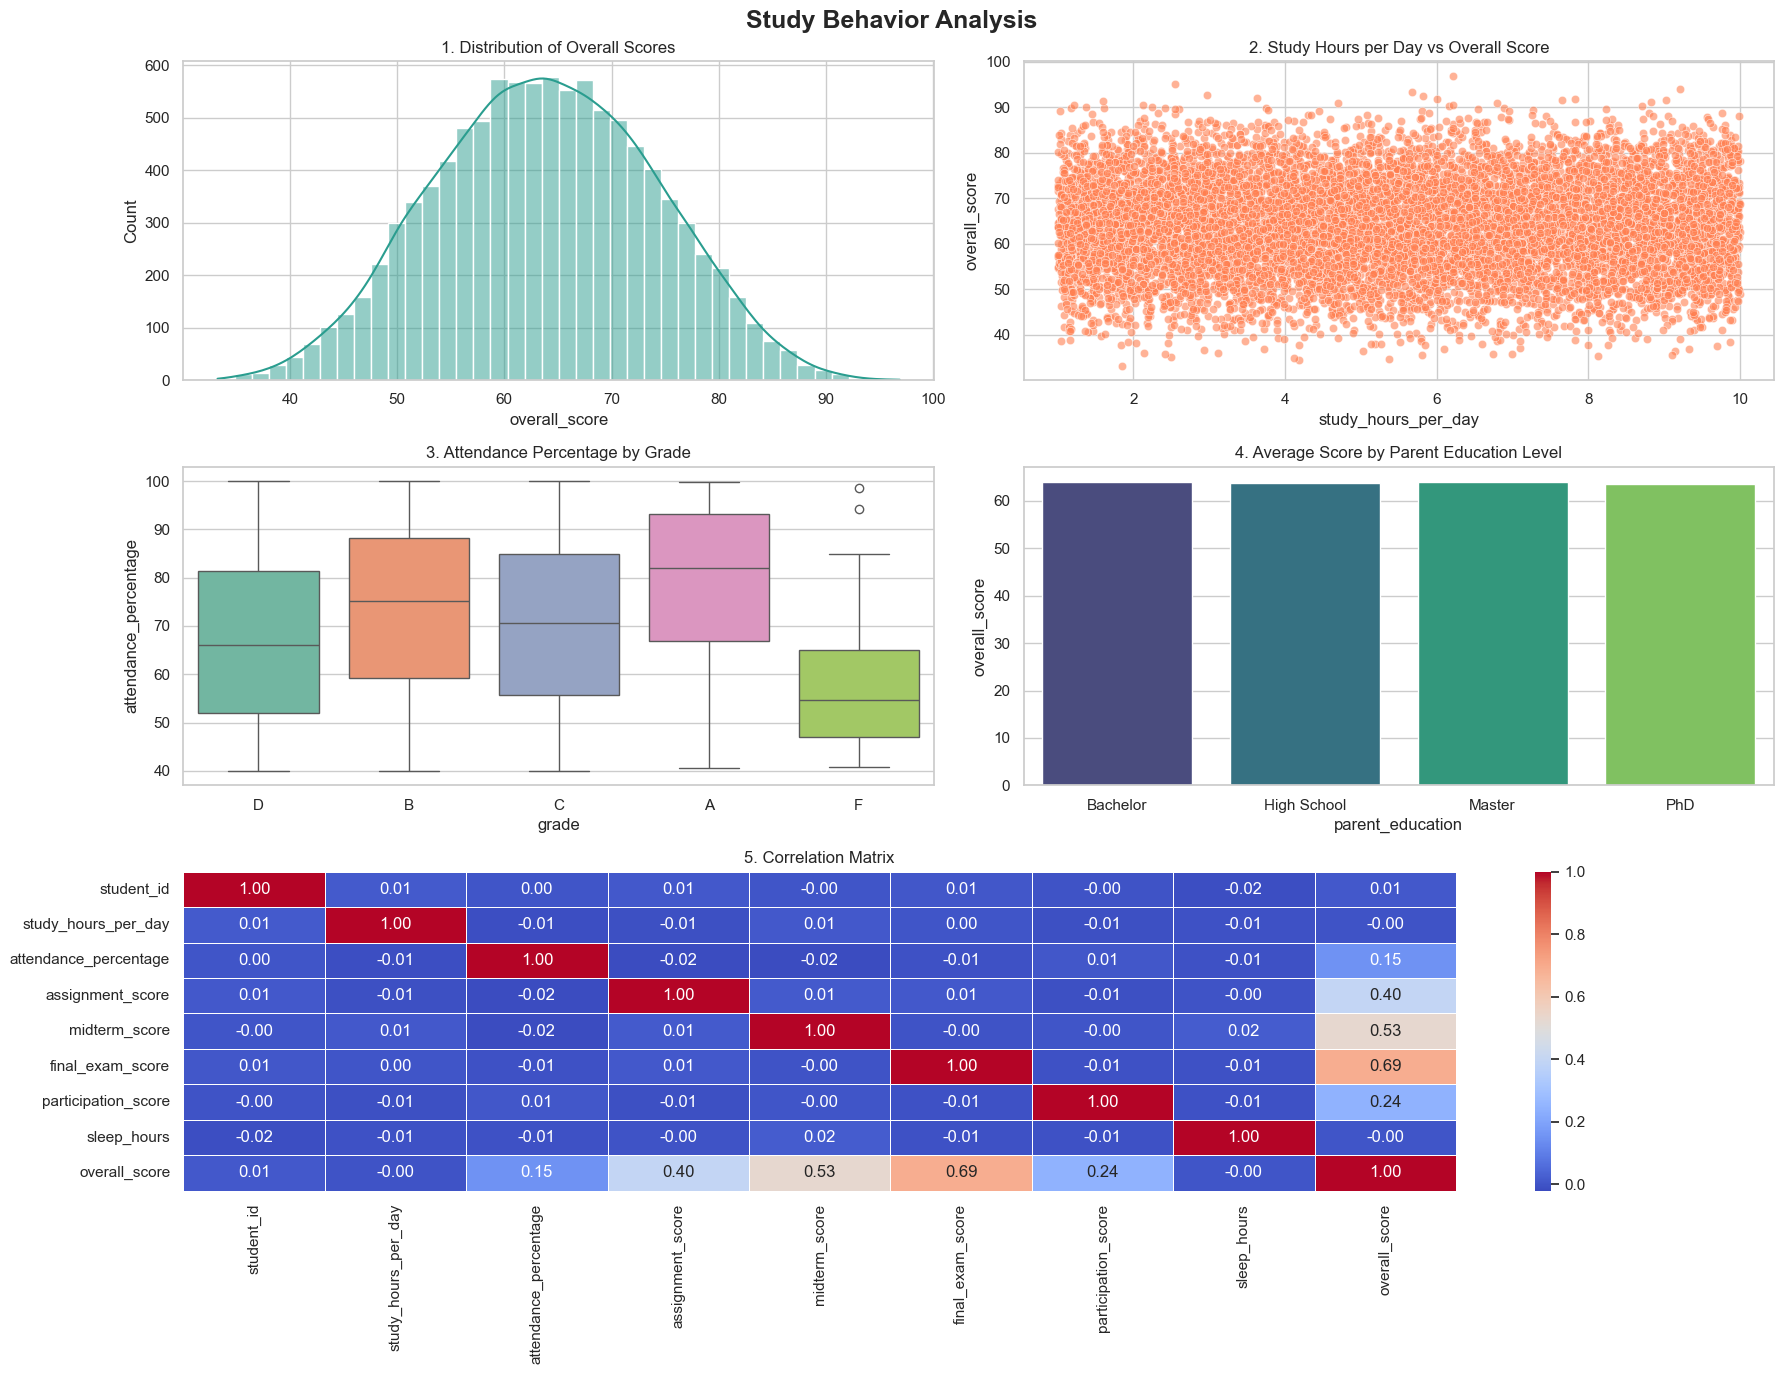

In [8]:
                                                            ##Study Behavior Analysis
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization theme style
sns.set_theme(style="whitegrid")

# Load dataset from CSV
df = pd.read_csv("data/student_performance_data.csv")

# Identify parent education column
if 'parent_education_level' in df.columns:
    parent_col = 'parent_education_level'
elif 'parent_education' in df.columns:
    parent_col = 'parent_education'
elif 'parents_education' in df.columns:
    parent_col = 'parents_education'
else:
    parent_col = None

# Initialize main figure layout
fig = plt.figure(figsize=(18, 14))

# Plot overall score distribution
ax1 = plt.subplot(3, 2, 1)

sns.histplot(
    df['overall_score'],
    bins=40,
    kde=True,
    color="#2a9d8f",
    ax=ax1
)

ax1.set_title("1. Distribution of Overall Scores")

# Plot study hours correlation
ax2 = plt.subplot(3, 2, 2)

sns.scatterplot(
    data=df,
    x='study_hours_per_day',
    y='overall_score',
    color="#ff7f50",
    alpha=0.6,
    ax=ax2
)

ax2.set_title("2. Study Hours per Day vs Overall Score")

# Plot attendance by grade
ax3 = plt.subplot(3, 2, 3)

sns.boxplot(
    data=df,
    x='grade',
    y='attendance_percentage',
    palette="Set2",
    hue='grade',      
    legend=False,
    ax=ax3
)

ax3.set_title("3. Attendance Percentage by Grade")

# Plot parent education impact
ax4 = plt.subplot(3, 2, 4)

if parent_col:
    parent_avg = df.groupby(parent_col)['overall_score'].mean().reset_index()

    sns.barplot(
        data=parent_avg,
        x=parent_col,
        y='overall_score',
        palette="viridis",
        hue=parent_col,     
        legend=False,
        ax=ax4
    )

    ax4.set_title("4. Average Score by Parent Education Level")
else:
    ax4.text(0.5, 0.5, "Parent Education Column Not Found", 
             ha='center', va='center')
    ax4.set_title("4. Missing Data")


# Plot variables correlation matrix
ax5 = plt.subplot(3, 1, 3)

corr = df.select_dtypes(include='number').corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5,
    ax=ax5
)

ax5.set_title("5. Correlation Matrix")
plt.suptitle("Study Behavior Analysis", fontsize=18, fontweight='bold')

# Adjust layout and display
plt.tight_layout()
plt.show()

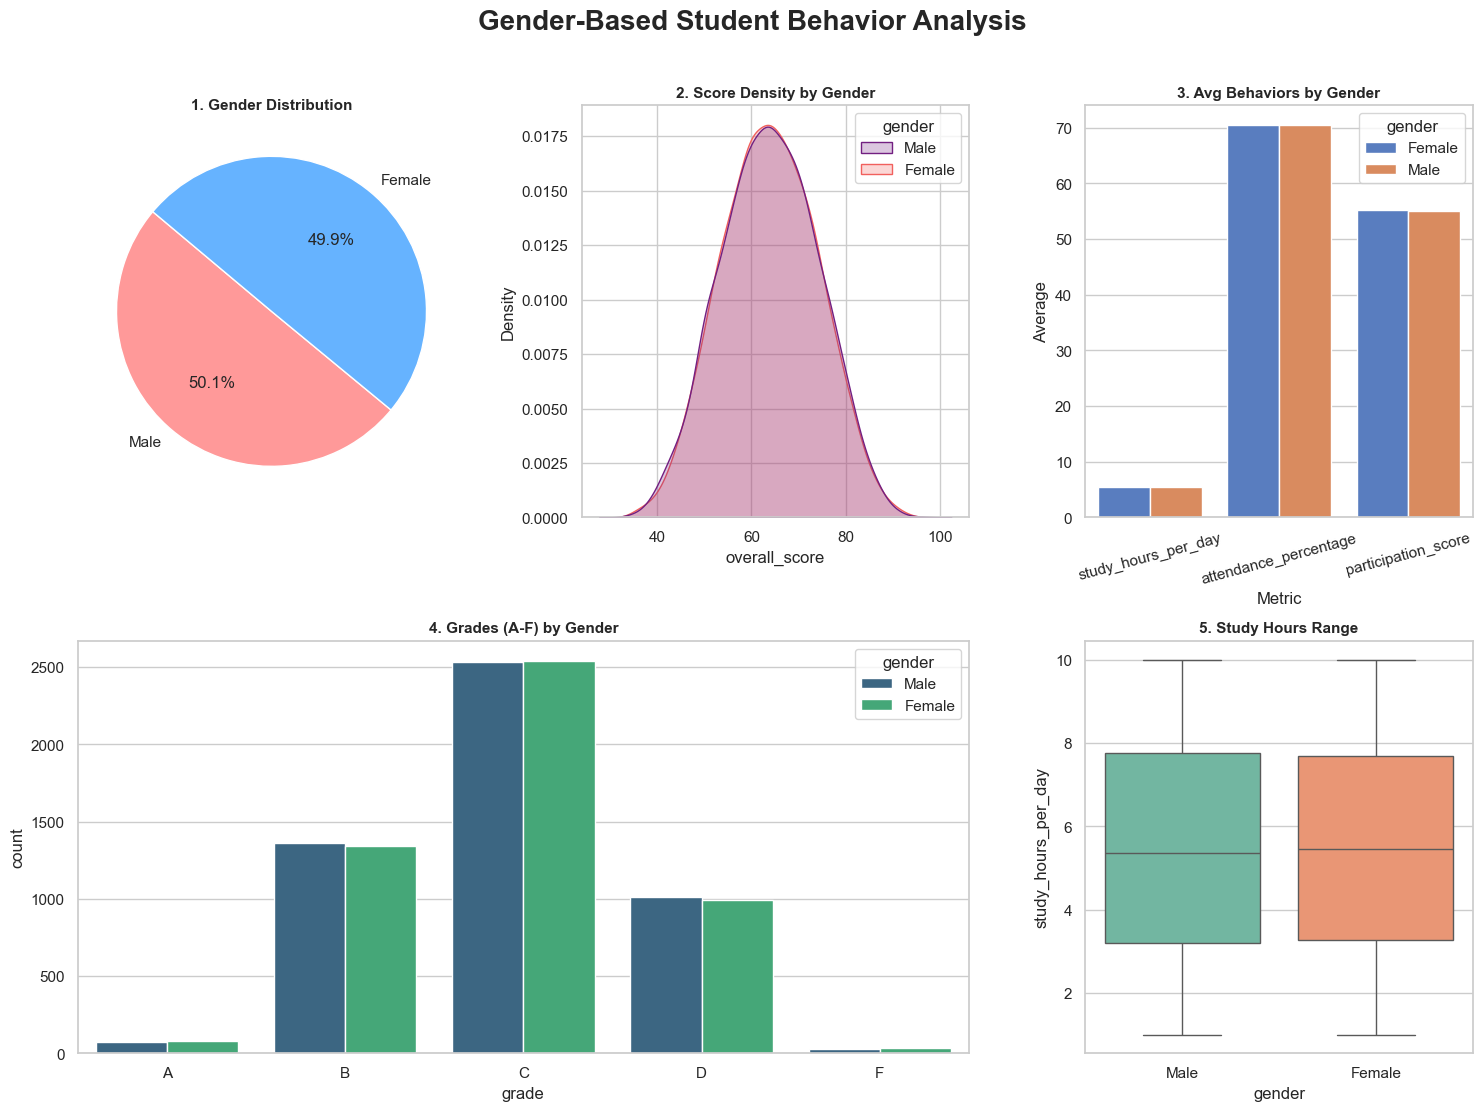

In [9]:
                                                                 ##Gender Analysis
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Load and prepare dataset
df = pd.read_csv('data/student_performance_data.csv')
sns.set_theme(style="whitegrid")

# Define dashboard figure layout
fig = plt.figure(figsize=(18, 12))
grid = plt.GridSpec(2, 3, hspace=0.3, wspace=0.3)

# Plot gender distribution ratio
ax1 = fig.add_subplot(grid[0, 0])
gender_counts = df['gender'].value_counts()
ax1.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', colors=['#ff9999','#66b3ff'], startangle=140)
ax1.set_title('1. Gender Distribution', fontsize=11, fontweight='bold')

# Plot score density comparison
ax2 = fig.add_subplot(grid[0, 1])
sns.kdeplot(data=df, x='overall_score', hue='gender', fill=True, palette='magma', ax=ax2)
ax2.set_title('2. Score Density by Gender', fontsize=11, fontweight='bold')

# Plot behavior metrics average
ax3 = fig.add_subplot(grid[0, 2])
metrics = df.groupby('gender')[['study_hours_per_day', 'attendance_percentage', 'participation_score']].mean().reset_index()
metrics_melted = metrics.melt(id_vars='gender', var_name='Metric', value_name='Average')
sns.barplot(data=metrics_melted, x='Metric', y='Average', hue='gender', palette='muted', ax=ax3)
ax3.set_title('3. Avg Behaviors by Gender', fontsize=11, fontweight='bold')
plt.xticks(rotation=15)

# Plot grade frequency count
ax4 = fig.add_subplot(grid[1, 0:2])
grade_order = sorted(df['grade'].unique())
sns.countplot(data=df, x='grade', hue='gender', order=grade_order, palette='viridis', ax=ax4)
ax4.set_title('4. Grades (A-F) by Gender', fontsize=11, fontweight='bold')

# Plot study hours range
ax5 = fig.add_subplot(grid[1, 2])
sns.boxplot(
    data=df,
    x='gender',
    y='study_hours_per_day',
    hue='gender',
    palette=["#66c2a5", "#fc8d62"],
    legend=False,
    ax=ax5
)
ax5.set_title('5. Study Hours Range', fontsize=11, fontweight='bold')

# Set main dashboard title
plt.suptitle("Gender-Based Student Behavior Analysis",
             fontsize=20,
             fontweight='bold')

plt.subplots_adjust(top=0.90)

# Save and display results
plt.savefig('gender_analysis_dashboard.png', bbox_inches='tight')
plt.show()

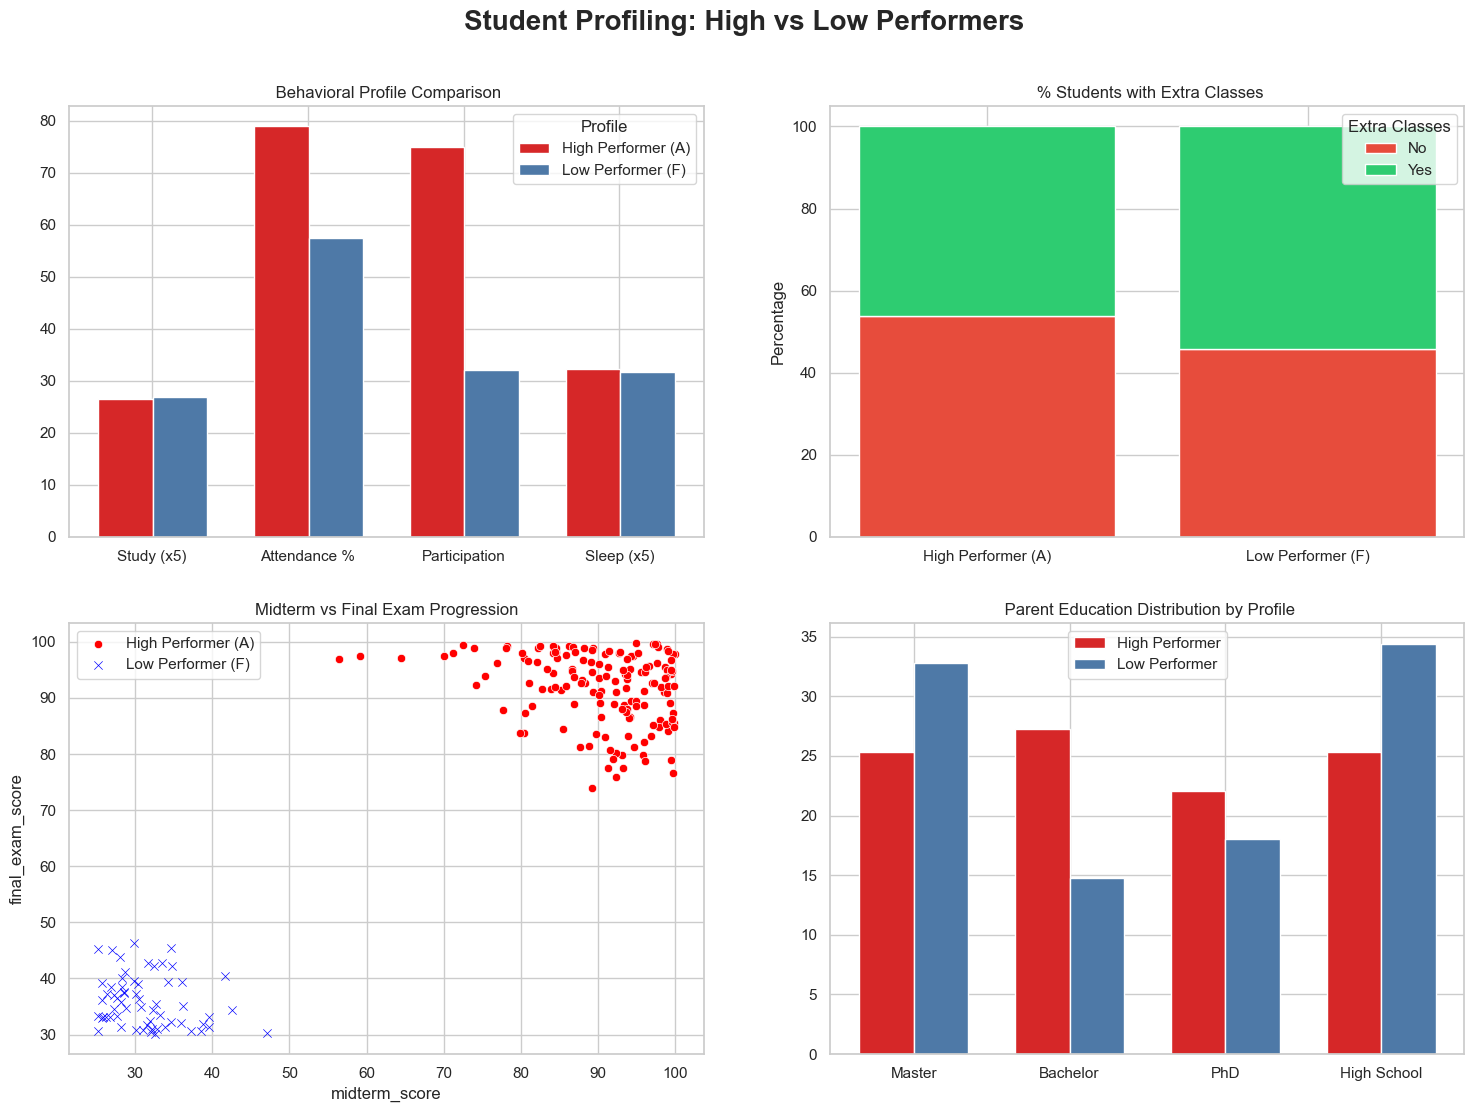

In [ ]:
                                                                              ##student profiling 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual theme style
sns.set_theme(style="whitegrid")

# Load performance dataset
df = pd.read_csv("data/student_performance_data.csv")

# Segment high and low performers
high_perf = df[df['grade'] == 'A']
low_perf = df[df['grade'] == 'F']

# Initialize figure for profiling
fig = plt.figure(figsize=(18, 12))

# Compare behavioral metrics averages
ax1 = plt.subplot(2, 2, 1)

metrics = ['study_hours_per_day', 'attendance_percentage', 'participation_score', 'sleep_hours']

high_means = high_perf[metrics].mean()
low_means = low_perf[metrics].mean()

high_vals = [
    high_means['study_hours_per_day'] * 5,
    high_means['attendance_percentage'],
    high_means['participation_score'],
    high_means['sleep_hours'] * 5
]

low_vals = [
    low_means['study_hours_per_day'] * 5,
    low_means['attendance_percentage'],
    low_means['participation_score'],
    low_means['sleep_hours'] * 5
]

labels = ['Study (x5)', 'Attendance %', 'Participation', 'Sleep (x5)']
x = range(len(labels))

ax1.bar(x, high_vals, width=0.35, label='High Performer (A)', color='#d62728')
ax1.bar([i + 0.35 for i in x], low_vals, width=0.35, label='Low Performer (F)', color='#4e79a7')

ax1.set_xticks([i + 0.17 for i in x])
ax1.set_xticklabels(labels)
ax1.set_title(" Behavioral Profile Comparison")
ax1.legend(title="Profile")


# Compare extra classes enrollment
ax2 = plt.subplot(2, 2, 2)

extra_high = high_perf['extra_classes'].value_counts(normalize=True) * 100
extra_low = low_perf['extra_classes'].value_counts(normalize=True) * 100

labels2 = ['High Performer (A)', 'Low Performer (F)']

no_vals = [extra_high.get('No', 0), extra_low.get('No', 0)]
yes_vals = [extra_high.get('Yes', 0), extra_low.get('Yes', 0)]

ax2.bar(labels2, no_vals, label='No', color='#e74c3c')
ax2.bar(labels2, yes_vals, bottom=no_vals, label='Yes', color='#2ecc71')

ax2.set_title(" % Students with Extra Classes")
ax2.set_ylabel("Percentage")
ax2.legend(title="Extra Classes")

# Plot exam score progression
ax3 = plt.subplot(2, 2, 3)

sns.scatterplot(
    data=high_perf,
    x='midterm_score',
    y='final_exam_score',
    color='red',
    label='High Performer (A)',
    ax=ax3
)

sns.scatterplot(
    data=low_perf,
    x='midterm_score',
    y='final_exam_score',
    color='blue',
    marker='x',
    label='Low Performer (F)',
    ax=ax3
)

ax3.set_title("Midterm vs Final Exam Progression")

# Compare parent education distribution
ax4 = plt.subplot(2, 2, 4)

categories = df['parent_education'].dropna().unique()

high_vals = [(high_perf['parent_education'] == cat).mean() * 100 for cat in categories]
low_vals = [(low_perf['parent_education'] == cat).mean() * 100 for cat in categories]

x = range(len(categories))
width = 0.35

high_color = '#d62728'   
low_color = '#4e79a7'    

ax4.bar(x, high_vals, width, label='High Performer', color=high_color)
ax4.bar([i + width for i in x], low_vals, width, label='Low Performer', color=low_color)

ax4.set_xticks([i + width/2 for i in x])
ax4.set_xticklabels(categories)
ax4.set_title(" Parent Education Distribution by Profile")
ax4.legend()

# Set main profiling title
plt.suptitle("Student Profiling: High vs Low Performers",
             fontsize=20,
             fontweight='bold')

# Adjust layout and show
plt.subplots_adjust(top=0.90)
plt.show()